# Mini Trabalho de DAA - Análise de Redes Ficcionais
### Ano Letivo 2024/25

**Trabalho realizado por:**
* Daniel de Matos Masqueiro, nº 129853
* Dinis Soares Sousa, nº 129820

In [ ]:
import csv
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

class Vertex:
    def __init__(self, vertex_id):
        self._vertex_id = vertex_id
    def __hash__(self): return hash(self._vertex_id)
    def __str__(self): return 'v{0}'.format(self._vertex_id)
    def __eq__(self, vertex):
        if not isinstance(vertex, Vertex): return False
        return self._vertex_id == vertex._vertex_id
    def vertex_id(self): return self._vertex_id

class Edge:
    def __init__(self, vertex_1, vertex_2, weight):
        self._vertex_1, self._vertex_2, self._weight = vertex_1, vertex_2, weight
    def __hash__(self): return hash((self._vertex_1, self._vertex_2))
    def __str__(self): return 'e({0},{1})w={2}'.format(self._vertex_1, self._vertex_2, self._weight)
    def endpoints(self): return (self._vertex_1, self._vertex_2)
    def cost(self): return self._weight
    def opposite(self, vertex):
        if vertex == self._vertex_1: return self._vertex_2
        elif vertex == self._vertex_2: return self._vertex_1
        return None

class Graph:
    def __init__(self):
        self._adjancencies = {}
        self._vertices = {}
        self._n = 0
        self._m = 0
    def order(self): return self._n
    def size(self): return self._m
    def has_vertex(self, vertex_id): return vertex_id in self._vertices
    def has_edge(self, u_id, v_id):
        if not self.has_vertex(u_id) or not self.has_vertex(v_id): return False
        return self._vertices[v_id] in self._adjancencies[self._vertices[u_id]]
    def insert_vertex(self, vertex_id):
        if not self.has_vertex(vertex_id):
            vertex = Vertex(vertex_id)
            self._vertices[vertex_id] = vertex
            self._adjancencies[vertex] = {}
            self._n += 1
    def insert_edge(self, u_id, v_id, weight=0):
        if not self.has_vertex(u_id): self.insert_vertex(u_id)
        if not self.has_vertex(v_id): self.insert_vertex(v_id)      
        if not self.has_edge(u_id, v_id): self._m += 1
        vertex_u, vertex_v = self._vertices[u_id], self._vertices[v_id]
        e = Edge(vertex_u, vertex_v, weight)    
        self._adjancencies[vertex_u][vertex_v] = e
        self._adjancencies[vertex_v][vertex_u] = e
    def degree(self, vertex_id): return len(self._adjancencies[self._vertices[vertex_id]])
    def get_vertex(self, vertex_id): return self._vertices.get(vertex_id)
    def vertices(self): return self._vertices.values()
    def edges(self):
        seen = set()
        for adj_map in self._adjancencies.values():
            for edge in adj_map.values():
                if edge not in seen:
                    yield edge
                    seen.add(edge)
    def incident_edges(self, vertex_id):
        vertex = self._vertices[vertex_id]
        for edge in self._adjancencies[vertex].values(): yield edge
    def remove_vertex(self, vertex_id):
        if self.has_vertex(vertex_id):
            lst_copied = list(self.incident_edges(vertex_id))
            for edge in lst_copied:
                x, y = edge.endpoints()
                self.remove_edge(x.vertex_id(), y.vertex_id())
            del self._adjancencies[self._vertices[vertex_id]]
            del self._vertices[vertex_id]
            self._n -= 1
    def remove_edge(self, u_id, v_id):
        if self.has_edge(u_id, v_id):
            vertex_u, vertex_v = self._vertices[u_id], self._vertices[v_id]
            del self._adjancencies[vertex_u][vertex_v]
            if vertex_u != vertex_v: del self._adjancencies[vertex_v][vertex_u]
            self._m -= 1

# 1. API CentralityAnalyzer
## 1.1. Análise de Complexidade

A classe CentralityAnalyzer foi concebida para integrar o cálculo de métricas de centralidade e conectividade, utilizando como base a representação de grafos por dicionários encadeados . A complexidade espacial da aplicação é estimada em $O(n + m)$, uma vez que a estrutura de dados interna armazena cada vértice e cada aresta do grafo de forma eficiente. No que concerne à complexidade temporal, o método degree_centrality opera em $O(n)$, enquanto a closeness_centrality e a betweenness_centrality (através do algoritmo de Brandes) apresentam uma complexidade de $O(n \cdot (n + m))$ por exigirem uma travessia BFS a partir de cada um dos $n$ vértices do grafo. A eigenvector_centrality, implementada via Power Iteration, possui uma complexidade de $O(k \cdot m)$ por iteração, onde $k$ é o número de iterações necessárias para atingir a convergência numérica.

## 1.2. Construtor e Estrutura de Dados

> **Nota para Daniel e Dinis:** Devem inserir aqui a vossa estimativa teórica do espaço de memória total utilizado pela aplicação em termos de $n$ e $m$ (explicando o porquê do $O(n+m)$ com base nos atributos da classe que inicializam no método abaixo).

In [ ]:
class CentralityAnalyzer:
    def __init__(self, graph):
        self._graph = graph
        self._n = graph.order()
        self._m = graph.size()
        self._vertex_ids = [v.vertex_id() for v in graph.vertices()]

    def bfs(self, source):
        distances = {source: 0}; predecessors = {source: []}; sigma = {source: 1}
        queue = deque([source]); order = []
        while queue:
            u_id = queue.popleft()
            order.append(u_id)
            for edge in self._graph.incident_edges(u_id):
                v_id = edge.opposite(self._graph.get_vertex(u_id)).vertex_id()
                if v_id not in distances:
                    distances[v_id] = distances[u_id] + 1
                    queue.append(v_id)
                    sigma[v_id] = 0
                    predecessors[v_id] = []
                if distances[v_id] == distances[u_id] + 1:
                    sigma[v_id] += sigma.get(u_id, 0)
                    predecessors[v_id].append(u_id)
        return distances, predecessors, sigma, order

    def num_components(self):
        visited = set(); count = 0
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            if v_id not in visited:
                count += 1
                dist, _, _, _ = self.bfs(v_id)
                visited.update(dist.keys())
        return count

    def largest_component(self):
        visited = set(); largest_nodes = []
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            if v_id not in visited:
                dist, _, _, _ = self.bfs(v_id)
                component_nodes = list(dist.keys())
                if len(component_nodes) > len(largest_nodes): largest_nodes = component_nodes
                visited.update(component_nodes)
        sub = Graph()
        for v_id in largest_nodes: sub.insert_vertex(v_id)
        for edge in self._graph.edges():
            u_id, v_id = [v.vertex_id() for v in edge.endpoints()]
            if u_id in largest_nodes and v_id in largest_nodes:
                sub.insert_edge(u_id, v_id, edge.cost())
        return sub

    def degree_distribution(self):
        dist = {}
        for v in self._graph.vertices():
            deg = self._graph.degree(v.vertex_id())
            dist[deg] = dist.get(deg, 0) + 1
        return dist

    def diameter(self):
        lc = self.largest_component()
        max_dist = 0
        temp_analyzer = CentralityAnalyzer(lc)
        for v in lc.vertices():
            dists, _, _, _ = temp_analyzer.bfs(v.vertex_id())
            local_max = max(dists.values()) if dists else 0
            if local_max > max_dist: max_dist = local_max
        return max_dist

    def degree_centrality(self):
        res = {}; n = self._n
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            res[v_id] = self._graph.degree(v_id) / (n - 1) if n > 1 else 0
        return res

    def closeness_centrality(self):
        res = {}; n = self._n
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            dists, _, _, _ = self.bfs(v_id)
            r_v = len(dists) - 1 
            sum_d = sum(dists.values())
            res[v_id] = (r_v**2) / ((n - 1) * sum_d) if sum_d > 0 and n > 1 else 0.0
        return res

    def eigenvector_centrality(self, epsilon=1e-6, max_iter=100):
        scores = {v.vertex_id(): 1.0 for v in self._graph.vertices()}
        for k in range(max_iter):
            new_scores = {}
            for v in self._graph.vertices():
                v_id = v.vertex_id()
                s = sum(scores[edge.opposite(v).vertex_id()] for edge in self._graph.incident_edges(v_id))
                new_scores[v_id] = s
            max_val = max(new_scores.values()) if new_scores else 1
            if max_val > 0:
                for v_id in new_scores: new_scores[v_id] /= max_val
            diff = max(abs(new_scores[v_id] - scores[v_id]) for v_id in scores)
            scores = new_scores
            if diff < epsilon: return scores, k + 1
        return scores, max_iter

    def betweenness_centrality(self):
        n = self._n
        bc = {v.vertex_id(): 0.0 for v in self._graph.vertices()}
        for s_v in self._graph.vertices():
            s_id = s_v.vertex_id()
            dists, preds, sigma, order = self.bfs(s_id)
            delta = {v.vertex_id(): 0.0 for v in self._graph.vertices()}
            while order:
                w_id = order.pop()
                for v_id in preds.get(w_id, []):
                    delta[v_id] += (sigma[v_id] / sigma[w_id]) * (1 + delta[w_id])
                if w_id != s_id: bc[w_id] += delta[w_id]
        norm = (n - 1) * (n - 2) / 2 if n > 2 else 1
        for v_id in bc: bc[v_id] /= norm
        return bc

# 2. Análise Estrutural dos Grafos
## 2.1. Travessia BFS

> **Nota para Daniel e Dinis:** Descrevam aqui o funcionamento do algoritmo BFS, a estrutura de dados auxiliar utilizada (Fila/deque) e a justificação passo a passo para a complexidade $O(n+m)$ (que não coube no resumo global de 1.1).

## 2.2. Conectividade

> **Nota para Daniel e Dinis:** Apresentem aqui a justificação da complexidade temporal dos métodos de conectividade `num_components()` e `largest_component()`.

In [ ]:
def carregar_grafo(caminho):
    g = Graph()
    with open(caminho, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            # Tenta ir buscar o 'weight' (minúsculo), se não encontrar tenta o 'Weight' (maiúsculo)
            peso = row.get('weight', row.get('Weight'))
            g.insert_edge(row['Source'], row['Target'], float(peso))
    return g

# Função para encontrar o caminho usando os predecessores da BFS
def encontrar_caminho(analyzer, origem, destino):
    if not analyzer._graph.has_vertex(origem) or not analyzer._graph.has_vertex(destino):
        return None
    
    _, preds, _, _ = analyzer.bfs(origem)
    
    if destino not in preds or not preds[destino]:
        return None # Não há caminho
    
    caminho = [destino]
    atual = destino
    while atual != origem:
        atual = preds[atual][0] # Pega num dos predecessores possíveis
        caminho.append(atual)
        
    caminho.reverse() # Inverter para ficar Origem -> Destino
    return caminho

# Carregamento dos Datasets
g_book1 = carregar_grafo('got_book1.csv')
g_full = carregar_grafo('got_full.csv')

analyzer_book1 = CentralityAnalyzer(g_book1)
analyzer_full = CentralityAnalyzer(g_full)

# Execução da Análise Global
for nome, analyzer in [("Livro 1", analyzer_book1), ("Saga Completa", analyzer_full)]:
    n_comp = analyzer.num_components()
    lc = analyzer.largest_component()
    print(f"--- {nome} ---")
    print(f"Conexo: {'Sim' if n_comp == 1 else 'Não'}")
    print(f"Nº Componentes: {n_comp}")
    print(f"Ordem da Maior Componente: {lc.order()}\n")

# Teste do Caminho (Pergunta 3)
p1 = "Jon-Snow"
p2 = "Daenerys-Targaryen"
caminho = encontrar_caminho(analyzer_full, p1, p2)

print("--- Teste de Conexão Específica (Saga Completa) ---")
if caminho:
    print(f"O caminho entre {p1} e {p2} tem {len(caminho)-1} arestas:")
    print(" -> ".join(caminho))
else:
    print(f"Não existe caminho entre {p1} e {p2}.")

--- Livro 1 ---
Conexo: Sim
Nº Componentes: 1
Ordem da Maior Componente: 187

--- Saga Completa ---
Conexo: Sim
Nº Componentes: 1
Ordem da Maior Componente: 796

--- Teste de Conexão Específica (Saga Completa) ---
O caminho entre Jon-Snow e Daenerys-Targaryen tem 2 arestas:
Jon-Snow -> Cersei-Lannister -> Daenerys-Targaryen


### Conclusões da Secção 2.2

> **Nota para Daniel e Dinis:** Respondam aqui às seguintes questões do enunciado:
> 1. O grafo é conexo? Quantas componentes conexas existem?
> 2. Qual o tamanho da maior componente? Os vértices fora da maior componente têm alguma interpretação no contexto narrativo?
> 3. (Apresentem também o código/resultado para verificar o caminho entre dois personagens específicos à vossa escolha).
> 4. Comparem a estrutura de conectividade. A rede torna-se mais ou menos conexa ao longo dos livros da saga?

## 2.3. Distribuição de Graus e Top-10

> **Nota para Daniel e Dinis:**
> 1. Apresentem aqui a análise da complexidade temporal e espacial do método `degree_distribution()`.
> 2. Analisem os histogramas gerados no código abaixo: a distribuição segue uma lei de potência (cauda longa)? O que revela sobre a rede? 
> 3. Existem semelhanças/diferenças entre o universo Marvel e o Game of Thrones?
> 4. Analisem o Top-10: Os personagens mais conectados no livro 1 mantêm a posição na saga completa?

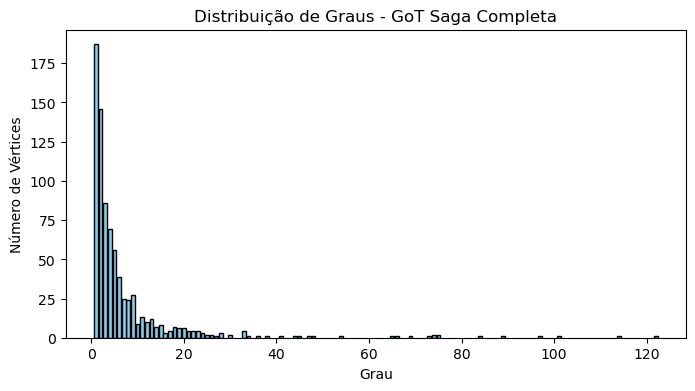

--- Top 10 (Grau) - GoT Livro 1 ---
1. Eddard-Stark: 66
2. Robert-Baratheon: 50
3. Tyrion-Lannister: 46
4. Catelyn-Stark: 43
5. Jon-Snow: 37
6. Robb-Stark: 35
7. Sansa-Stark: 35
8. Bran-Stark: 32
9. Cersei-Lannister: 30
10. Joffrey-Baratheon: 30

--- Top 10 (Grau) - GoT Saga Completa ---
1. Tyrion-Lannister: 122
2. Jon-Snow: 114
3. Jaime-Lannister: 101
4. Cersei-Lannister: 97
5. Stannis-Baratheon: 89
6. Arya-Stark: 84
7. Catelyn-Stark: 75
8. Sansa-Stark: 75
9. Robb-Stark: 74
10. Eddard-Stark: 74



In [ ]:
def plot_degree_distribution(analyzer, title):
    dist = analyzer.degree_distribution()
    graus = list(dist.keys())
    contagens = list(dist.values())
    plt.figure(figsize=(8, 4))
    plt.bar(graus, contagens, color='skyblue', edgecolor='black')
    plt.title(f"Distribuição de Graus - {title}")
    plt.xlabel("Grau")
    plt.ylabel("Número de Vértices")
    plt.show()

def print_top10_graus(analyzer, title):
    dist = {v.vertex_id(): analyzer._graph.degree(v.vertex_id()) for v in analyzer._graph.vertices()}
    top10 = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"--- Top 10 (Grau) - {title} ---")
    for i, (v, score) in enumerate(top10, 1):
        print(f"{i}. {v}: {score}")
    print()

plot_degree_distribution(analyzer_full, "GoT Saga Completa")
print_top10_graus(analyzer_book1, "GoT Livro 1")
print_top10_graus(analyzer_full, "GoT Saga Completa")

## 2.4. Diâmetro

> **Nota para Daniel e Dinis:**
> 1. Indiquem o diâmetro obtido para cada dataset.
> 2. Apresentem um par de personagens que realize essa distância máxima e o respetivo caminho (podem usar o dicionário de predecessores do vosso BFS para extrair a lista exata do caminho).
> 3. Interpretem os resultados à luz da teoria dos "seis graus de separação".

In [ ]:
print("Calculando o diâmetro do Game of Thrones...")
diam_got = analyzer_full.diameter()
print(f"Diâmetro da maior componente (GoT Full): {diam_got}")

print("\nA carregar o grafo da Marvel (Full)...")
g_marvel_full = carregar_grafo('marvel_full.csv')
analyzer_marvel = CentralityAnalyzer(g_marvel_full)

print("A calcular o diâmetro da Marvel (Aviso: vai demorar alguns minutos!)...")
diam_marvel = analyzer_marvel.diameter()
print(f"Diâmetro da maior componente (Marvel Full): {diam_marvel}")

Calculando diâmetros (pode demorar alguns segundos)...
Diâmetro da maior componente (GoT Full): 9


NameError: name 'analyzer_marvel' is not defined

# 3. Métricas de Centralidade
## 3.1. Degree Centrality (DC)

> **Nota para Daniel e Dinis:**
> 1. Analisem a complexidade temporal e espacial deste método.
> 2. Comparem o Top-10 de DC com o Top-10 por grau da Secção 2.3. São iguais? Porquê?
> 3. Os personagens mais centrais do livro 1 são os mesmos da saga completa?

In [ ]:
def print_top10(centrality_dict, title):
    top10 = sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"--- Top 10: {title} ---")
    for i, (v, score) in enumerate(top10, 1):
        print(f"{i}. {v}: {score:.4f}")
    print()

dc_book1 = analyzer_book1.degree_centrality()
dc_full = analyzer_full.degree_centrality()
print_top10(dc_book1, "Degree Centrality - GoT Livro 1")
print_top10(dc_full, "Degree Centrality - GoT Saga Completa")

--- Top 10: Degree Centrality - GoT Livro 1 ---
1. Eddard-Stark: 0.3548
2. Robert-Baratheon: 0.2688
3. Tyrion-Lannister: 0.2473
4. Catelyn-Stark: 0.2312
5. Jon-Snow: 0.1989
6. Robb-Stark: 0.1882
7. Sansa-Stark: 0.1882
8. Bran-Stark: 0.1720
9. Cersei-Lannister: 0.1613
10. Joffrey-Baratheon: 0.1613

--- Top 10: Degree Centrality - GoT Saga Completa ---
1. Tyrion-Lannister: 0.1535
2. Jon-Snow: 0.1434
3. Jaime-Lannister: 0.1270
4. Cersei-Lannister: 0.1220
5. Stannis-Baratheon: 0.1119
6. Arya-Stark: 0.1057
7. Catelyn-Stark: 0.0943
8. Sansa-Stark: 0.0943
9. Robb-Stark: 0.0931
10. Eddard-Stark: 0.0931



## 3.2. Closeness Centrality (CC)

> **Nota para Daniel e Dinis:**
> 1. Analisem a complexidade temporal e espacial deste método.
> 2. (Apresentem aqui a validação manual exigida: os cálculos num grafo muito pequeno).
> 3. O Eddard-Stark surge no topo do Livro 1?
> 4. Identifiquem personagens cuja CC mais diminui após a remoção do Eddard (vejam o output do código). O que significa narrativamente a sua dependência do Eddard?

In [ ]:
cc_book1 = analyzer_book1.closeness_centrality()
print_top10(cc_book1, "Closeness Centrality - GoT Livro 1")

g_book1_sem_ned = carregar_grafo('got_book1.csv')
g_book1_sem_ned.remove_vertex('Eddard-Stark')
analyzer_sem_ned = CentralityAnalyzer(g_book1_sem_ned)
cc_sem_ned = analyzer_sem_ned.closeness_centrality()

deltas = {}
for v_id in cc_sem_ned:
    if v_id in cc_book1:
        deltas[v_id] = cc_book1[v_id] - cc_sem_ned[v_id]

top_quedas = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:5]
print("--- Maiores quedas de CC após remover Eddard-Stark ---")
for v, delta in top_quedas:
    print(f"{v}: Perdeu {delta:.4f} de CC")

--- Top 10: Closeness Centrality - GoT Livro 1 ---
1. Eddard-Stark: 0.5636
2. Robert-Baratheon: 0.5455
3. Tyrion-Lannister: 0.5110
4. Catelyn-Stark: 0.5054
5. Robb-Stark: 0.4973
6. Jon-Snow: 0.4934
7. Sansa-Stark: 0.4895
8. Bran-Stark: 0.4869
9. Cersei-Lannister: 0.4844
10. Joffrey-Baratheon: 0.4806

--- Maiores quedas de CC sem Eddard-Stark ---
Gendry: Perdeu 0.3612 de CC
Howland-Reed: Perdeu 0.3612 de CC
Jacks: Perdeu 0.3612 de CC
Joss: Perdeu 0.3612 de CC
Porther: Perdeu 0.3612 de CC


## 3.3. Eigenvector Centrality (EC)

> **Nota para Daniel e Dinis:**
> 1. Analisem a complexidade temporal e espacial (identificando o custo iterativo e de normalização).
> 2. (Apresentem a validação manual pedida no enunciado).
> 3. Comparem o Top-10 EC com o Top-10 DC (da Secção 3.1). Quem sobe/desce ou aparece/desaparece? Qual a justificação narrativa para isso acontecer no livro 1?

In [ ]:
ec_book1, k_iter = analyzer_book1.eigenvector_centrality()
print(f"Iterações até convergência: {k_iter}\n")
print_top10(ec_book1, "Eigenvector Centrality - GoT Livro 1")

Iterações até convergência: 16
--- Top 10: Eigenvector Centrality - GoT Livro 1 ---
1. Eddard-Stark: 1.0000
2. Robert-Baratheon: 0.9092
3. Sansa-Stark: 0.7812
4. Tyrion-Lannister: 0.7598
5. Joffrey-Baratheon: 0.7448
6. Cersei-Lannister: 0.7302
7. Catelyn-Stark: 0.7171
8. Petyr-Baelish: 0.6797
9. Jaime-Lannister: 0.6577
10. Bran-Stark: 0.6537



## 3.4. Betweenness Centrality (BC)

> **Nota para Daniel e Dinis:**
> 1. Analisem a complexidade temporal e espacial do algoritmo de Brandes.
> 2. (Apresentem a validação manual pedida no enunciado).
> 3. Comparem o Top-10 BC com o Top-10 CC (GoT Full). Expliquem narrativamente as diferenças e subidas/descidas nos rankings ao longo da saga.
> 4. Os personagens com maior BC no livro 1 mantêm esse papel na saga completa?

In [ ]:
bc_book1 = analyzer_book1.betweenness_centrality()
bc_full = analyzer_full.betweenness_centrality()
print_top10(bc_book1, "Betweenness Centrality - GoT Livro 1")
print_top10(bc_full, "Betweenness Centrality - GoT Saga Completa")

--- Top 10: Betweenness Centrality - GoT Livro 1 ---
1. Eddard-Stark: 0.5392
2. Robert-Baratheon: 0.4281
3. Tyrion-Lannister: 0.3804
4. Jon-Snow: 0.3432
5. Catelyn-Stark: 0.3028
6. Daenerys-Targaryen: 0.1725
7. Robb-Stark: 0.1460
8. Drogo: 0.1296
9. Bran-Stark: 0.1116
10. Sansa-Stark: 0.0743

--- Top 10: Betweenness Centrality - GoT Saga Completa ---
1. Jon-Snow: 0.3842
2. Tyrion-Lannister: 0.3244
3. Daenerys-Targaryen: 0.2368
4. Theon-Greyjoy: 0.2226
5. Stannis-Baratheon: 0.2203
6. Jaime-Lannister: 0.2017
7. Cersei-Lannister: 0.1774
8. Arya-Stark: 0.1745
9. Eddard-Stark: 0.1575
10. Robert-Baratheon: 0.1565



# 4. Análise Empírica do Tempo de Execução

Nesta secção, os tempos medidos representam a mediana de 5 execuções independentes para os grafos mais pequenos, e 1 única execução para o dataset `marvel_full`, devido à sua elevada ordem de complexidade temporal.

## 4.1. Escalabilidade dos Algoritmos

> **Nota para Daniel e Dinis:**
> 1. Analisem o gráfico gerado abaixo. A ordenação dos tempos $T_{DC}$, $T_{EC}$, $T_{CC}$ e $T_{BC}$ é consistente com as complexidades calculadas na Secção 3?
> 2. As retas no gráfico log-log têm declives diferentes para cada algoritmo? O que revela isso sobre a ordem de complexidade teórica de cada um?

In [ ]:
print("A carregar Marvel Small...")
g_marvel_small = carregar_grafo('marvel_small.csv')

analyzers = {
    'GoT Book 1': CentralityAnalyzer(g_book1),
    'GoT Full': CentralityAnalyzer(g_full),
    'Marvel Small': CentralityAnalyzer(g_marvel_small),
    'Marvel Full': CentralityAnalyzer(g_marvel_full)
}

tempos = {'DC': [], 'EC': [], 'CC': [], 'BC': []}
tamanhos_n_m = []
nomes_datasets = list(analyzers.keys())
k_iters = [] 

def medir_tempo(analyzer, metodo, nome_dataset):
    repeticoes = 1 if nome_dataset == 'Marvel Full' else 5
    tempos_medidos = []
    k_val = None
    for _ in range(repeticoes):
        inicio = time.time()
        if metodo == 'eigenvector_centrality':
            _, k_val = getattr(analyzer, metodo)()
        else:
            getattr(analyzer, metodo)()
        fim = time.time()
        tempos_medidos.append(fim - inicio)
    return np.median(tempos_medidos), k_val

print("A iniciar medições de tempo. (Atenção: Marvel Full vai demorar muito!)...")
for nome, analyzer in analyzers.items():
    print(f"A processar {nome}...")
    tamanhos_n_m.append(analyzer._n + analyzer._m)
    
    t_dc, _ = medir_tempo(analyzer, 'degree_centrality', nome)
    tempos['DC'].append(t_dc)
    
    t_ec, k = medir_tempo(analyzer, 'eigenvector_centrality', nome)
    tempos['EC'].append(t_ec)
    k_iters.append(k)
    
    t_cc, _ = medir_tempo(analyzer, 'closeness_centrality', nome)
    tempos['CC'].append(t_cc)
    
    t_bc, _ = medir_tempo(analyzer, 'betweenness_centrality', nome)
    tempos['BC'].append(t_bc)

print("Medições concluídas!")

A carregar os grafos da Marvel...
A iniciar medições de tempo. Por favor aguarde (O Marvel Full vai demorar!)...
A processar GoT Book 1...
A processar GoT Full...
A processar Marvel Small...
A processar Marvel Full...


KeyboardInterrupt: 

## 4.2. Comparação Empírica CC vs BC

> **Nota para Daniel e Dinis:**
> 1. Analisando o gráfico de barras abaixo, a razão $T_{BC}/T_{CC}$ é aproximadamente constante entre os diferentes datasets? 
> 2. O que isso implica sobre as constantes escondidas na notação $O()$ de cada algoritmo?
> 3. Com base na vossa implementação, qual é a operação exata que o Betweenness Centrality (BC) executa e que o Closeness Centrality (CC) não executa para justificar essa diferença de tempo (Pista: pensem na fase 2 de Brandes, o "retrocesso/back-propagation")?

In [ ]:
razao_bc_cc = [t_bc / t_cc for t_bc, t_cc in zip(tempos['BC'], tempos['CC'])]

plt.figure(figsize=(8, 5))
plt.bar(nomes_datasets, razao_bc_cc, color='coral', edgecolor='black')
for i, v in enumerate(razao_bc_cc):
    plt.text(i, v + 0.1, f"{v:.1f}x", ha='center', va='bottom')

plt.xlabel('Dataset')
plt.ylabel('Razão $T_{BC} / T_{CC}$')
plt.title('4.2 - Razão do tempo entre Betweenness e Closeness')
plt.grid(axis='y', linestyle='--')
plt.show()

## 4.3. Verificação $T_{CC}/T_{EC} \approx n/k$

> **Nota para Daniel e Dinis:**
> 1. Olhando para o gráfico de dispersão gerado, o declive observado pelos pontos é próximo de 1? O que isso confirma sobre a relação teórica sugerida no enunciado?
> 2. Os pontos aproximam-se da reta $y=x$, ou estão sistematicamente acima ou abaixo? Justifiquem este desvio com base nas constantes escondidas dos algoritmos (operações base de dicionários vs operações simples matemáticas).
> 3. O valor de iterações $k$ é semelhante entre os datasets? O que isso revela sobre a velocidade de convergência do método *Power Iteration* nestes tipos de grafos?

In [ ]:
razao_cc_ec = [t_cc / t_ec for t_cc, t_ec in zip(tempos['CC'], tempos['EC'])]
n_sobre_k = [analyzer._n / k for analyzer, k in zip(analyzers.values(), k_iters)]

plt.figure(figsize=(8, 6))
plt.scatter(n_sobre_k, razao_cc_ec, color='purple', s=100, zorder=5)

for i, nome in enumerate(nomes_datasets):
    plt.annotate(f"{nome}\n(k={k_iters[i]})", (n_sobre_k[i], razao_cc_ec[i]), 
                 textcoords="offset points", xytext=(10,-5), ha='left')

max_val = max(max(n_sobre_k), max(razao_cc_ec))
plt.plot([0, max_val*1.1], [0, max_val*1.1], color='red', linestyle='--', label='Reta Teórica $y=x$')

plt.xlabel('Razão Teórica ($n/k$)')
plt.ylabel('Razão Empírica ($T_{CC}/T_{EC}$)')
plt.title('4.3 - Verificação da relação $T_{CC}/T_{EC} \\approx n/k$')
plt.legend()
plt.grid(True, linestyle='--')
plt.xlim(0, max_val*1.2)
plt.ylim(0, max_val*1.2)
plt.show()

# 5. Questões Éticas

A resolução deste trabalho obedeceu aos princípios de integridade académica, garantindo que todas as explicações, código e análises apresentadas refletem o esforço e compreensão do grupo.

**5.1. Colaborações fora do grupo:**
> (Nota para Daniel e Dinis: Indiquem aqui se tiveram ajuda de colegas de outros grupos para perceber a matéria. Se não, escrevam apenas "Nenhuma" ou "Não aplicável").

**5.2. Fontes utilizadas:**
> (Nota para Daniel e Dinis: Devem listar os materiais usados. Podem deixar os que já coloquei abaixo e acrescentar outros sites/livros se for caso disso).
* Material disponibilizado na UC (Slides teóricos e laboratoriais).
* Documento de apoio ao minitrabalho DAA 2025/2026.
* Enunciado do Minitrabalho.